In [1]:
import warnings
import time
from __future__ import annotations
import datetime
from dataclasses import dataclass, field
from typing import Tuple, List, Dict, Optional
from functools import partial

import pandas as pd
import numpy as np
from category_encoders import CountEncoder
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier, Pool
from sklearn.neural_network import MLPClassifier
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
import matplotlib.pyplot as plt
import seaborn as sns

import keras
from keras import layers, models
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import ReduceLROnPlateau
import tensorflow as tf

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
plt.style.use("seaborn-v0_8")
RANDOM_STATE: int = 42

| Item          | Version  |
|-------------------|---------|
| Kernel            | Python 3.12.0 |
| sklearn           | 1.7.1   |
| pandas            | 2.3.2   |
| seaborn           | 0.13.2  |
| matplotlib        | 3.10.6  |
| code formatter    | black 25.1.0  |

In [2]:
notebook_time = time.time()

#### 1. Download data from Don’tGetKicked competition.

kaggle competitions download -c DontGetKicked<br>
or direct download

##### 1.1 Read all the data

In [3]:
path: str = "data/DontGetKicked/{name}.csv"
train_df: pd.DataFrame = pd.read_csv(path.format(name="training"), parse_dates=["PurchDate"])
test_df: pd.DataFrame = pd.read_csv(path.format(name="test"), parse_dates=["PurchDate"])

##### 1.2 Drop columns with N/A > 50%

In [4]:
NA_THRESHOLD: float = 0.5
NA_percent = train_df.isnull().mean()
to_drop = NA_percent[NA_percent >= NA_THRESHOLD].index
train_df_wo_na = train_df.drop(columns=to_drop)

##### 1.3 Simple impute N/A for other columns and scale numeric

In [5]:
TARGET: str = "IsBadBuy"
DATETIME_COL: str = "PurchDate"
numeric = (
    train_df_wo_na.drop(TARGET, axis=1)
    .select_dtypes(exclude=["object", "datetime"])
    .columns
)

categories = train_df_wo_na.select_dtypes(include="object").columns

numeric_pipeline = Pipeline(
    [
        ("num_imp", SimpleImputer(strategy="median")),
        ("st_scaler", StandardScaler()),
    ]
)

categories_pipeline = Pipeline(
    [
        ("cat_imp", SimpleImputer(strategy="constant", fill_value="unknown")),
    ]
)

col_tr = ColumnTransformer(
    transformers=[
        ("num_pipeline", numeric_pipeline, numeric),
        ("cat_pipeline", categories_pipeline, categories),
    ],
    remainder="drop",
)
train_df_tform_arr = col_tr.fit_transform(train_df_wo_na)

train_df_tform = pd.DataFrame(train_df_tform_arr)
train_df_tform.columns = numeric.to_list() + categories.to_list()
# add target and datetime col to final df
train_df_tform[DATETIME_COL] = train_df_wo_na[DATETIME_COL]
train_df_tform[TARGET] = train_df_wo_na[TARGET]

##### 1.4 Design the train/validation/test split. <br>Use the "PurchDate" field for the split, test must be later than validation, same for validation and train: train.PurchDate < valid.PurchDate < test.PurchDate. <br>Use the first 1/3 of dates for the train, the last 1/3 of dates for the test, and the middle 1/3 for the validation set. Don’t use the test dataset until the end!

In [6]:
def split_by_date_percentiles(
    X: pd.DataFrame,
    shift: int,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:

    info = X.dtypes
    date_in_df = [pd.api.types.is_datetime64_ns_dtype(x) for x in info.values]
    if not any(date_in_df):
        raise ValueError("No date col in df")

    date_col = info.index[date_in_df.index(True)]

    X = X.sort_values(by=date_col)

    unique_dates = X[date_col].unique()
    n_dates = len(unique_dates)

    train_threshold = unique_dates[n_dates // 3 + shift]
    val_threshold = unique_dates[2 * n_dates // 3 + shift]

    X_train = X[X[date_col] <= train_threshold]
    X_valid = X[(X[date_col] > train_threshold) & (X[date_col] <= val_threshold)]
    X_test = X[X[date_col] > val_threshold]

    assert X_train[date_col].max() < X_valid[date_col].min()
    assert X_valid[date_col].max() < X_test[date_col].min()

    return X_train, X_valid, X_test


def check_split(df_list: List[pd.DataFrame], df_initial: pd.DataFrame) -> None:
    final_set: set = set(df_initial.index)
    for df in df_list:
        final_set -= set(df.index)
    print(final_set == set())
    [print(round(len(x) / len(df_initial), 2), end=" ") for x in df_list]


X_train, X_valid, X_test = split_by_date_percentiles(train_df_tform, shift=8)
check_split(df_list=[X_train, X_valid, X_test], df_initial=train_df_tform)

True
0.33 0.33 0.33 

##### 1.5 Use LabelEncoder or OneHotEncoder from sklearn to preprocess categorical variables.<br> Be careful with data leakage (fit Encoder to training and apply to validation & test).<br> Consider another coding approach if you encounter new categorical values in validation & test (not seen in training):<br> https://contrib.scikit-learn.org/category_encoders/count.html

In [7]:
cat_to_onehot_enc: list = []
cat_to_target_enc: list = []

for category in categories:
    # if there is many unique values we cant use OHE
    if X_train[category].value_counts().count() < 21:
        cat_to_onehot_enc.append(category)
    else:
        cat_to_target_enc.append(category)

# to avoid dummy variable trap use drop='first'
# when feature matrix becomes singular (determinant = 0)
one_hot_enc = OneHotEncoder(
    sparse_output=False,
    drop="first",
    feature_name_combiner="concat",
    handle_unknown="ignore",
)
cat_one_hot_enc = one_hot_enc.fit(X_train[cat_to_onehot_enc])

count_enc = CountEncoder(normalize=True, min_group_size=15)
cat_count_enc = count_enc.fit(X_train[cat_to_target_enc])

df_transformed: list = []

for df in [X_train, X_valid, X_test]:
    cat_one_hot_enc = one_hot_enc.transform(df[cat_to_onehot_enc])
    cat_one_hot_enc = pd.DataFrame(
        cat_one_hot_enc, columns=one_hot_enc.get_feature_names_out()
    )

    cat_count_enc = count_enc.transform(df[cat_to_target_enc])
    combined = pd.concat(
        [
            df[numeric].reset_index(drop=True),
            cat_count_enc.reset_index(drop=True),
            cat_one_hot_enc.reset_index(drop=True),
            df[TARGET].reset_index(drop=True),
        ],
        axis=1,
    )
    df_transformed.append(combined)

X_train, X_valid, X_test = df_transformed

In [8]:
y_train = X_train[TARGET]
X_train = X_train.drop(TARGET, axis=1).astype(np.float64)
y_valid = X_valid[TARGET]
X_valid = X_valid.drop(TARGET, axis=1).astype(np.float64)
y_test = X_test[TARGET]
X_test = X_test.drop(TARGET, axis=1).astype(np.float64)

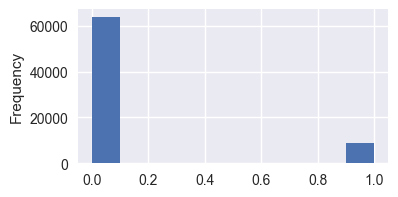

In [9]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(4, 2))
train_df[TARGET].plot.hist(ax=ax)
fig.show()

Target classes are imbalanced

In [10]:
def gini_score_sk(y_true, y_score):
    """using 2*ROC AUC - 1 approach"""
    return round(2 * roc_auc_score(y_true=y_true, y_score=y_score) - 1, 4)

#### 2. Create a Python class, MLP with 1 hidden layer and sigmoid activation function at the end of the network.<br>It should support fit, predict_proba and predict methods. <br>Also, the number of neurons in the hidden layer and the activation function must be parameters of your class

Here is the blueprint:

```python
model = MLP(n_hidden=100, activation=np.arctan)
model.fit(Xtrain, ytrain)
model.predict_proba(Xvalid)
```

- Initialize the network with small random numbers.
- Use Log Loss (Binary Cross Entropy) as the loss function.
- Implement a forward pass; you can use a fixed batch size like 32, forward pass maps arrays of shape <br>(batch_size, number_of_features) to arrays of shape (batch_size, 2) where 2 means dimensions of [probability_of_0, probability_of_1] output space.
- Write down the gradients of the loss function with respect to the parameters of the net. Use [4](https://en.wikipedia.org/wiki/Backpropagation), [9](http://d2l.ai/) as a guide for deriving gradients.
- Use gradients to perform Backprop. Implement Backprop.
- Implement SGD algorithm to tune model parameters.
- Design a basic train-validation loop: iterate over the training dataset, batch by batch, update the parameters of the network, and check the quality of the model using the validation set.
- Write code to update network weights using SGD or Adam.

In [11]:
@dataclass
class MLPClassifier_:
    """
    Multilayer Perceptron (MLP) - a simplified sklearn-like implementation
    """

    hidden_layer_sizes: List[int] = field(default_factory=lambda: [100])
    learning_rate: float = 0.01
    batch_size: int = 32
    max_iter: int = 200
    tol: float = 1e-4
    random_state: int = RANDOM_STATE
    activation: str = "relu"
    solver: str = "sgd"
    verbose: bool = False

    def __post_init__(self):
        self.weights: dict = {}
        self.gradients: dict = {}
        self.training_loss: list = []
        self.validation_scores: list = []

        if self.solver == "adam":
            self.adam_w = {
                "beta1": 0.9,
                "beta2": 0.999,
                "epsilon": 1e-8,
                "m": {},  # 1st moment vector
                "v": {},  # 2nd moment vector
                "t": 0,
            }
        np.random.seed(self.random_state)

    def fit(self, X: np.ndarray, y: np.ndarray, val_size: float = 0.1):
        X, y = np.asarray(X), np.asarray(y)

        X_train, X_val, y_train, y_val = train_test_split(
            X, y, test_size=val_size, random_state=self.random_state, stratify=y
        )

        y_train_one_hot = np.eye(2)[y_train.astype(int)]
        y_val_one_hot = np.eye(2)[y_val.astype(int)]

        self._initialize_parameters(X_train.shape[1])

        n_samples = X_train.shape[0]
        indices = np.arange(n_samples)
        self.convergence = 0

        for epoch in range(self.max_iter):
            np.random.shuffle(indices)
            epoch_loss, n_batches = 0, 0

            for start in range(0, n_samples, self.batch_size):
                batch_indices = indices[start : start + self.batch_size]
                X_batch = X_train[batch_indices]
                y_batch = y_train_one_hot[batch_indices]

                cache, y_pred = self.forward_pass(X_batch)

                batch_loss = self._log_loss(y_batch, y_pred)
                epoch_loss += batch_loss
                n_batches += 1

                gradients = self._compute_gradients(X_batch, y_batch, cache)

                if self.solver == "adam":
                    self._update_parameters_adam(gradients)
                else:
                    self._update_parameters_sgd(gradients)

            avg_epoch_loss = epoch_loss / n_batches
            self.training_loss.append(avg_epoch_loss)

            if avg_epoch_loss <= self.tol:
                self.convergence = 1
                break

            # validation (early stopping if validation loss increases could be implemented)
            self._validation(X_val, y_val_one_hot, y_val, epoch, avg_epoch_loss)

        return self

    def _initialize_parameters(self, n_features: int, n_classes: int = 2):
        layer_sizes = [n_features] + self.hidden_layer_sizes + [n_classes]
        self.n_layers = len(layer_sizes) - 1

        for i in range(len(layer_sizes) - 1):
            # init Xavier/Glorot for better convergence
            scale = np.sqrt(2.0 / (layer_sizes[i] + layer_sizes[i + 1]))
            self.weights[f"W{i + 1}"] = (
                np.random.randn(layer_sizes[i], layer_sizes[i + 1]) * scale
            )
            self.weights[f"b{i + 1}"] = np.zeros((1, layer_sizes[i + 1]))

            # init for Adam
            if self.solver == "adam":
                self.adam_w["m"][f"W{i + 1}"] = np.zeros_like(self.weights[f"W{i + 1}"])
                self.adam_w["m"][f"b{i + 1}"] = np.zeros_like(self.weights[f"b{i + 1}"])
                self.adam_w["v"][f"W{i + 1}"] = np.zeros_like(self.weights[f"W{i + 1}"])
                self.adam_w["v"][f"b{i + 1}"] = np.zeros_like(self.weights[f"b{i + 1}"])

    def forward_pass(self, X: np.ndarray) -> Tuple[Dict[str, np.ndarray], np.ndarray]:
        cache: dict = {}
        A = X.copy()

        for i in range(self.n_layers):
            # Z(logit) = W·X + b
            Z = A @ self.weights[f"W{i + 1}"] + self.weights[f"b{i + 1}"]
            cache[f"Z{i + 1}"] = Z

            if i != self.n_layers - 1:
                # A(Activated)
                A = self._activation(Z)
            else:
                # out layer with softmax instead of hidden layers activation
                A = self._softmax(Z)
            cache[f"A{i + 1}"] = A

        return cache, A

    def _activation(self, Z: np.ndarray, derivative: bool = False) -> np.ndarray:
        if self.activation == "relu":
            if derivative:
                return (Z > 0).astype(float)
            return np.maximum(0, Z)

        # tanh(z) = (e^z - e^(-z)) / (e^z + e^(-z))
        elif self.activation == "tanh":
            # sigmoidlike func
            if derivative:
                return 1 - np.tanh(Z) ** 2
            return np.tanh(Z)

        # Sigmoid: σ(z) = 1 / (1 + e^(-z))
        elif self.activation == "sigmoid":
            if derivative:
                sigmoid = 1 / (1 + np.exp(-Z))
                return sigmoid * (1 - sigmoid)
            # sigmoid(500) ≈ 1.0, sigmoid(-500) ≈ 0.0
            return 1 / (1 + np.exp(-np.clip(Z, -500, 500)))

        elif self.activation == "cosine":
            if derivative:
                return -np.sin(Z)
            return np.cos(Z)

    def _softmax(self, Z: np.ndarray) -> np.ndarray:
        exp_Z = np.exp(Z - np.max(Z, axis=1, keepdims=True))
        return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

    def _log_loss(self, y_true: np.ndarray, y_pred: np.ndarray) -> float:
        """Log Loss (Binary Cross Entropy)"""
        eps = 1e-15
        y_pred = np.clip(y_pred, eps, 1 - eps)
        # y_true в one-hot encoding, y_pred - class probabilityes
        return -np.mean(np.sum(y_true * np.log(y_pred), axis=1))

    def _compute_gradients(
        self, X: np.ndarray, y: np.ndarray, cache: Dict[str, np.ndarray]
    ) -> Dict[str, np.ndarray]:
        """Compute gradients via backpropagation"""
        gradients: dict = {}
        n = X.shape[0]

        # Gradient for the output layer (softmax + log loss): dL/dZ = A - y
        dZ = cache[f"A{self.n_layers}"] - y

        for i in range(self.n_layers, 0, -1):
            A_prev = cache[f"A{i - 1}"] if i > 1 else X

            # current layer
            gradients[f"dW{i}"] = (A_prev.T @ dZ) / n
            gradients[f"db{i}"] = np.sum(dZ, axis=0, keepdims=True) / n

            if i > 1:
                # prev layer
                dA_prev = dZ @ self.weights[f"W{i}"].T
                Z_prev = cache[f"Z{i - 1}"]
                dZ = dA_prev * self._activation(Z_prev, derivative=True)

        return gradients

    def _update_parameters_sgd(self, gradients: Dict[str, np.ndarray]):
        for key in self.weights:
            self.weights[key] -= self.learning_rate * gradients[f"d{key}"]

    def _update_parameters_adam(self, gradients: Dict[str, np.ndarray]):
        self.adam_w["t"] += 1
        t = self.adam_w["t"]

        for key in self.weights:
            self.adam_w["m"][key] = (
                self.adam_w["beta1"] * self.adam_w["m"][key]
                + (1 - self.adam_w["beta1"]) * gradients[f"d{key}"]
            )
            self.adam_w["v"][key] = (
                self.adam_w["beta2"] * self.adam_w["v"][key] 
                + (1 - self.adam_w["beta2"]) * (gradients[f"d{key}"] ** 2)
            )

            m_hat = self.adam_w["m"][key] / (1 - self.adam_w["beta1"] ** t)
            v_hat = self.adam_w["v"][key] / (1 - self.adam_w["beta2"] ** t)

            self.weights[key] -= (
                self.learning_rate * m_hat / (np.sqrt(v_hat) + self.adam_w["epsilon"])
            )

    def _validation(
        self,
        X_val: np.ndarray,
        y_val_one_hot: np.ndarray,
        y_val: np.ndarray,
        epoch: int,
        avg_epoch_loss: float,
    ):

        val_pred = self.predict_proba(X_val)
        val_loss = self._log_loss(y_val_one_hot, val_pred)
        val_accuracy = np.mean(np.argmax(val_pred, axis=1) == y_val)
        self.validation_scores.append(val_accuracy)

        if self.verbose and (epoch + 1) % 25 == 0:
            print(
                f"Epoch {epoch + 1}/{self.max_iter}, "
                f"Train Loss: {avg_epoch_loss:.4f}, "
                f"Val Loss: {val_loss:.4f}, "
                f"Val Acc: {val_accuracy:.4f}"
            )

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        X = np.asarray(X)
        _, y_pred = self.forward_pass(X)
        return y_pred

    def predict(self, X: np.ndarray) -> np.ndarray:
        y_pred = self.predict_proba(X)
        return np.argmax(y_pred, axis=1)

    def score(self, X: np.ndarray, y: np.ndarray) -> float:
        y_pred = self.predict(X)
        return np.mean(y_pred == y)

#### 3. With your MLP module and careful network engineering, you must obtain at least a 0.15 Gini score on the validation dataset.<br> You can train for more than 1 epoch, use different activation functions, and different optimizers (like SGD or Adam).

In [12]:
out: pd.DataFrame = pd.DataFrame(
    {"model": [], "Gini(X_valid)": [], "Fit_time": [], "Predict_time": []}
)


def calc_metrics_for_model(model, out: pd.DataFrame, model_name: str):
    start_time = time.time()

    if "catboost" in model_name.lower():
        catboost_train = Pool(X_train, label=y_train)
        catboost_valid = Pool(X_valid, label=y_valid)
        model.fit(
            catboost_train,
            eval_set=catboost_valid,
            early_stopping_rounds=100,
            verbose=False,
        )
    else:
        model.fit(X=X_train, y=y_train)

    fit_time = round(time.time() - start_time, 4)
    start_time = time.time()
    y_pred = model.predict_proba(X=X_valid)[:, 1]
    predict_time = round(time.time() - start_time, 4)
    out.loc[len(out)] = {
        "model": model.__class__.__name__ if not model_name else model_name,
        "Gini(X_valid)": gini_score_sk(y_true=y_valid, y_score=y_pred),
        "Fit_time": fit_time,
        "Predict_time": predict_time,
    }

In [13]:
# add best linear from ML4 (naive hyperoptimization, not optuna)
# with all features (not X.loc[:, best_features] like in ML4)
LogReg = LogisticRegression(
    C=0.004944,
    penalty="l1",
    solver="liblinear",
    class_weight="balanced",
    random_state=RANDOM_STATE,
)
calc_metrics_for_model(LogReg, out, "LogisticRegression_ML4")

# add best CART from ML5 (naive hyperoptimization, not optuna)
best_params: dict = {
    "eval_metric": "AUC",
    "leaf_estimation_iterations": 10,
    "random_seed": 42,
    "verbose": False,
    "early_stopping_rounds": 100,
    "learning_rate": 0.05,
    "max_depth": 5,
}
CatBoost_model = CatBoostClassifier(**best_params)
calc_metrics_for_model(CatBoost_model, out, "CatBoost_ML5")

In [14]:
for solver in ("sgd", "adam"):
    mlp_sk = MLPClassifier_(
        activation="relu",
        solver=solver,
        random_state=RANDOM_STATE,
    )
    calc_metrics_for_model(mlp_sk, out, f"MLPClassifier_ relu_{solver}_base")
out

,model,Gini(X_valid),Fit_time,Predict_time
0,LogisticRegression_ML4,0.4806,0.0766,0.0075
1,CatBoost_ML5,0.4898,2.5079,0.0050
2,MLPClassifier_ relu_sgd_base,0.3909,20.2500,0.0255
3,MLPClassifier_ relu_adam_base,0.2569,31.9243,0.0295


#### 4. Use sklearn's MLPClassifier and check its performance on the validation dataset. Is it better than your module? If so, why?

In [15]:
# common sklearn model
for solver in ("sgd", "adam"):
    mlp_sk = MLPClassifier(
        activation="relu",
        solver=solver,
        random_state=RANDOM_STATE,
    )
    calc_metrics_for_model(mlp_sk, out, f"MLPClassifier_sk relu_{solver}_base")
out

,model,Gini(X_valid),Fit_time,Predict_time
0,LogisticRegression_ML4,0.4806,0.0766,0.0075
1,CatBoost_ML5,0.4898,2.5079,0.0050
2,MLPClassifier_ relu_sgd_base,0.3909,20.2500,0.0255
3,MLPClassifier_ relu_adam_base,0.2569,31.9243,0.0295
4,MLPClassifier_sk relu_sgd_base,0.4605,13.5377,0.0173
5,MLPClassifier_sk relu_adam_base,0.3288,19.2899,0.0183


Sklearn MLPClassifier is better because it's implemented with many internal optimiztions that is not presented in MLPClassifier_.<br>
Optuna version is the best because of sharp optimization after study.

#### 5. Implement and try different activation functions: sigmoid, ReLU, cosine.<br>Remember that you have to derive gradients for each different activation function.<br>Which activation function gives the best performance on the validation dataset?

In [16]:
out_activation: pd.DataFrame = pd.DataFrame(
    {"model": [], "Gini(X_valid)": [], "Fit_time": [], "Predict_time": []}
)
activation_list: list = ["relu", "tanh", "sigmoid", "cosine"]

for activation in activation_list:
    mlp_relu_sgd = MLPClassifier_(
        activation=activation,
        solver="sgd",
        random_state=RANDOM_STATE,
        verbose=False,
    )
    calc_metrics_for_model(
        mlp_relu_sgd, out_activation, f"MLPClassifier_ {activation}_sgd"
    )

out_activation.sort_values(by="Gini(X_valid)", ascending=False).reset_index(drop=True)

,model,Gini(X_valid),Fit_time,Predict_time
0,MLPClassifier_ sigmoid_sgd,0.4704,27.1912,0.0651
1,MLPClassifier_ tanh_sgd,0.4526,33.0614,0.0623
2,MLPClassifier_ relu_sgd,0.3909,20.1190,0.0341
3,MLPClassifier_ cosine_sgd,0.3693,23.5716,0.0343


logistic (sigmoid) gives the best perfomance because of small neuron structure

In [17]:
# hyperparametr optimisation
optuna_time = time.time()
# to make optuna study deterministic
np.random.seed(RANDOM_STATE)


def objective(trial, X_train, y_train, X_valid, y_valid):
    params = {
        "hidden_layer_sizes": trial.suggest_categorical(
            "hidden_layer_sizes",
            [
                (32,), (64,), (128,),
                (32, 16), (64, 32), (128, 64),
            ],
        ),
        "solver": trial.suggest_categorical("solver", ["adam", "sgd"]),
        "learning_rate_init": trial.suggest_float(
            "learning_rate_init", 1e-5, 0.1, log=True
        ),
        "alpha": trial.suggest_float("alpha", 1e-5, 0.1, log=True),
        "batch_size": trial.suggest_categorical("batch_size", [32, 64, 128, 256]),
        "max_iter": trial.suggest_int("max_iter", 200, 1200, step=100),
        "activation": trial.suggest_categorical("activation", ["relu", "tanh"]),
        "early_stopping": True,
        "validation_fraction": trial.suggest_float("validation_fraction", 0.1, 0.2),
        "n_iter_no_change": trial.suggest_int("n_iter_no_change", 10, 40),
        "random_state": RANDOM_STATE,
        "verbose": False,
        "tol": trial.suggest_float("tol", 1e-6, 1e-3, log=True),
    }

    if params["solver"] == "sgd":
        params["momentum"] = trial.suggest_float("momentum", 0.5, 0.99)

    model = MLPClassifier(**params).fit(X_train, y_train)
    y_pred = model.predict_proba(X_valid)[:, 1]
    return roc_auc_score(y_valid, y_pred)


study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    pruner=MedianPruner(n_startup_trials=10, n_warmup_steps=20),
)

study.optimize(
    lambda t: objective(t, X_train, y_train, X_valid, y_valid),
    n_trials=75,
    show_progress_bar=True,
    n_jobs=1,
)
total_optuna = time.time() - optuna_time
print(f"{total_optuna // 60}m {(total_optuna % 60):.1f}s")

  0%|          | 0/75 [00:00<?, ?it/s]

9.0m 54.3s


In [18]:
mlp_optuna = MLPClassifier(
    **study.best_params, random_state=RANDOM_STATE, early_stopping=True
)

act: str = study.best_params["activation"]
sol: str = study.best_params["solver"]
hid: str = study.best_params["hidden_layer_sizes"]

calc_metrics_for_model(
    mlp_optuna, out, f"optuna_MLPClassifier_sk  {act}_{sol}_hid:{hid}"
)
out

,model,Gini(X_valid),Fit_time,Predict_time
0,LogisticRegression_ML4,0.4806,0.0766,0.0075
1,CatBoost_ML5,0.4898,2.5079,0.0050
2,MLPClassifier_ relu_sgd_base,0.3909,20.2500,0.0255
3,MLPClassifier_ relu_adam_base,0.2569,31.9243,0.0295
4,MLPClassifier_sk relu_sgd_base,0.4605,13.5377,0.0173
5,MLPClassifier_sk relu_adam_base,0.3288,19.2899,0.0183
6,"optuna_MLPClassifier_sk relu_adam_hid:(32, 16)",0.4952,10.6178,0.0244


#### 6. Design an MLP module with 1 hidden layer using any high level deep learning framework: Pytorch, Keras, or Tensorflow. <br>Check its performance on the validation dataset. Is it better than your module? If so, why?

In [19]:
# make Pytorch model deterministic
torch.manual_seed(RANDOM_STATE)
torch.cuda.manual_seed(RANDOM_STATE)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


class PyTorchMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims=[100], dropout=0.3):
        super(PyTorchMLP, self).__init__()
        layers = []
        prev_dim = input_dim

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, 1))
        layers.append(nn.Sigmoid())

        self.network = nn.Sequential(*layers)

    def fit(
        self,
        X,
        y,
        epochs=100,
        batch_size=32,
        learning_rate=0.001,
        validation_split=0.2,
        early_stopping_patience=10,
        reduce_lr_patience=5,
    ):

        X_tensor = torch.FloatTensor(X.values)
        y_tensor = torch.FloatTensor(y.values).reshape(-1, 1)

        val_size = int(validation_split * len(X_tensor))
        train_size = len(X_tensor) - val_size

        indices = torch.randperm(len(X_tensor))
        train_indices = indices[:train_size]
        val_indices = indices[train_size:]

        X_train, X_valid = X_tensor[train_indices], X_tensor[val_indices]
        y_train, y_valid = y_tensor[train_indices], y_tensor[val_indices]

        train_dataset = TensorDataset(X_train, y_train)
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

        criterion = nn.BCELoss()
        optimizer = optim.Adam(self.parameters(), lr=learning_rate)

        scheduler = ReduceLROnPlateau(
            optimizer,
            mode="min",
            patience=reduce_lr_patience,
            factor=0.5,
        )

        best_val_loss, patience_counter, best_model_state = float("inf"), 0, None

        for _ in range(epochs):
            self.train()
            total_loss = 0
            for batch_X, batch_y in train_loader:
                optimizer.zero_grad()
                outputs = self.forward(batch_X)
                loss = criterion(outputs, batch_y)
                loss.backward()
                optimizer.step()
                total_loss += loss.item()

            self.eval()
            with torch.no_grad():
                val_outputs = self.forward(X_valid)
                val_loss = criterion(val_outputs, y_valid)

            # Learning rate scheduling
            scheduler.step(val_loss)

            # Early stopping
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                best_model_state = {k: v.clone() for k, v in self.state_dict().items()}
            else:
                patience_counter += 1

            if patience_counter >= early_stopping_patience:
                if best_model_state is not None:
                    self.load_state_dict(best_model_state)
                break

        return self

    def forward(self, x):
        return self.network(x)

    def predict_proba(self, X):
        self.eval()
        with torch.no_grad():
            X_tensor = torch.FloatTensor(X.values)
            outputs = self.network(X_tensor)
            proba = outputs.numpy()
            return np.hstack([1 - proba, proba])


pytorch_model = PyTorchMLP(input_dim=X_train.shape[1])
calc_metrics_for_model(pytorch_model, out, "PyTorch_MLP")

In [20]:
# make Keras model deterministic
keras.utils.set_random_seed(RANDOM_STATE)


@dataclass
class KerasMLP:
    input_dim: int
    hidden_dims: List[int] = field(default_factory=lambda: [100])
    dropout: float = 0.3
    learning_rate: float = 0.001
    epochs: int = 100
    batch_size: int = 32
    validation_split: float = 0.2
    verbose: int = 0

    def __post_init__(self):
        self.model = None
        self._build_model()

    def _build_model(self):
        model = models.Sequential()
        model.add(layers.Input(shape=(self.input_dim,)))

        for hidden_dim in self.hidden_dims:
            model.add(layers.Dense(hidden_dim, activation="relu"))
            model.add(layers.BatchNormalization())
            model.add(layers.Dropout(self.dropout))

        model.add(layers.Dense(1, activation="sigmoid"))

        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=self.learning_rate),
            loss="binary_crossentropy",
            metrics=["accuracy"],
        )

        self.model = model

    def fit(self, X, y, verbose=0):
        self.model.fit(
            X,
            y,
            epochs=self.epochs,
            batch_size=self.batch_size,
            validation_split=self.validation_split,
            verbose=verbose,
        )
        return self

    def predict_proba(self, X):
        proba = self.model.predict(X, verbose=0)
        return np.hstack([1 - proba, proba])


keras_model = KerasMLP(input_dim=X_train.shape[1])
calc_metrics_for_model(keras_model, out, "Keras_MLP")

In [21]:
# make TensorFlowM model deterministic
tf.random.set_seed(RANDOM_STATE)
tf.config.experimental.enable_op_determinism()


@dataclass
class TensorFlowMLP:
    input_dim: int
    hidden_dims: List[int] = field(default_factory=lambda: [100])
    dropout: float = 0.3
    learning_rate: float = 0.001
    epochs: int = 100
    batch_size: int = 32
    validation_split: float = 0.2
    verbose: int = 0

    def __post_init__(self):
        self.model = None
        self._build_model()

    def _build_model(self):
        model = tf.keras.Sequential()
        model.add(tf.keras.layers.Input(shape=(self.input_dim,)))

        for hidden_dim in self.hidden_dims:
            model.add(tf.keras.layers.Dense(hidden_dim, activation="relu"))
            model.add(tf.keras.layers.BatchNormalization())
            model.add(tf.keras.layers.Dropout(self.dropout))

        model.add(tf.keras.layers.Dense(1, activation="sigmoid"))

        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=self.learning_rate),
            loss="binary_crossentropy",
            metrics=["accuracy"],
        )

        self.model = model

    def fit(self, X, y, verbose=0):
        early_stopping = tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=10, restore_best_weights=True
        )

        self.model.fit(
            X,
            y,
            epochs=self.epochs,
            batch_size=self.batch_size,
            validation_split=self.validation_split,
            verbose=verbose,
            callbacks=[early_stopping],
        )
        return self

    def predict_proba(self, X):
        proba = self.model.predict(X, verbose=0)
        return np.hstack([1 - proba, proba])


tf_model = TensorFlowMLP(input_dim=X_train.shape[1])
calc_metrics_for_model(tf_model, out, "TensorFlow_MLP")
out

,model,Gini(X_valid),Fit_time,Predict_time
0,LogisticRegression_ML4,0.4806,0.0766,0.0075
1,CatBoost_ML5,0.4898,2.5079,0.0050
2,MLPClassifier_ relu_sgd_base,0.3909,20.2500,0.0255
3,MLPClassifier_ relu_adam_base,0.2569,31.9243,0.0295
4,MLPClassifier_sk relu_sgd_base,0.4605,13.5377,0.0173
5,MLPClassifier_sk relu_adam_base,0.3288,19.2899,0.0183
6,"optuna_MLPClassifier_sk relu_adam_hid:(32, 16)",0.4952,10.6178,0.0244
7,PyTorch_MLP,0.4579,26.7610,0.0047
8,Keras_MLP,0.3712,100.6586,0.7628
9,TensorFlow_MLP,0.4395,19.8356,0.8406


#### 7. Take the best model and estimate its performance on the test dataset:<br> check the Gini scores on all three datasets for your best model: training Gini, valid Gini, test Gini.<br> Do you see a drop in performance when comparing the valid quality to the test quality? Is your model overfitting or not? Explain

In [22]:
f_out: dict = {
    "Model": [
        "CatBoost_model",
        "LogReg",
        "optuna_MLPClassifier_sk relu_adam",
    ],
    "Train_Gini": [],
    "Valid_Gini": [],
    "Test_Gini": [],
    "Train –> Valid diff, %": [],
    "Valid –> Test diff, %": [],
}

for num, model in enumerate((CatBoost_model, LogReg, mlp_optuna)):

    for x, y, name in (
        (X_train, y_train, "Train"),
        (X_valid, y_valid, "Valid"),
        (X_test, y_test, "Test"),
    ):

        y_pred = model.predict_proba(X=x)[:, 1]
        f_out[f"{name}_Gini"].append(gini_score_sk(y_true=y, y_score=y_pred))

    train_valid = f_out["Valid_Gini"][num] / f_out["Train_Gini"][num]
    valid_test = f_out["Test_Gini"][num] / f_out["Valid_Gini"][num]

    f_out["Train –> Valid diff, %"].append(round(train_valid - 1, 3) * 100)
    f_out["Valid –> Test diff, %"].append(round(valid_test - 1, 3) * 100)

pd.DataFrame(f_out)

,Model,Train_Gini,Valid_Gini,Test_Gini,"Train –> Valid diff, %","Valid –> Test diff, %"
0,CatBoost_model,0.5784,0.4898,0.5040,-15.3,2.9
1,LogReg,0.4957,0.4806,0.4993,-3.0,3.9
2,optuna_MLPClassifier_sk relu_adam,0.5279,0.4952,0.5135,-6.2,3.7


Best model in case of the best balance - optuna_MLPClassifier_sk.<br><br>
Do you see a drop in performance when comparing the valid quality to the test quality?<br>No, it's the other way around.<br><br>
Is your model overfitted or not? Explain.<br>Yes, optuna_MLPClassifier_sk model shows mild (train->valid -6.2%) overfitting.<br><br>
One of the possible causes is unbalanced distribution of the target variable between samples:

In [23]:
pd.DataFrame(
    {
        "Train": y_train.value_counts(normalize=True) * 100,
        "Valid": y_valid.value_counts(normalize=True) * 100,
        "Test": y_test.value_counts(normalize=True) * 100,
    }
).round(2)

,Train,Valid,Test
IsBadBuy,,,
0,88.52,87.0,87.6
1,11.48,13.0,12.4


#### Bonus part.
#### B1. Implement the Adam algorithm to tune the parameters of the model.


Implemented in MLPClassifier_

non-recursive form depending only on g

### $ \hat{m}_t = \frac{1}{1-\beta_1^t} (1-\beta_1)\sum_{s=1}^t \beta_1^{t-s} g_s $
### $ \hat{v}_t = \frac{1}{1-\beta_2^t} (1-\beta_2)\sum_{s=1}^t \beta_2^{t-s} g_s^2 $
### $ w_{t+1} = w_t - \frac{\alpha}{\sqrt{\hat{v}_t}} \hat{m}_t $

recursive   
### $ m_t = β₁·m_{t-1} + (1-β₁)·g_t $
### $ v_t = β₂·v_{t-1} + (1-β₂)·g_t² $
### $ m̂_t = m_t / (1 - β₁ᵗ) $
### $ v̂_t = v_t / (1 - β₂ᵗ) $
### $ w_{t+1} = w_t - α · m̂_t / (√v̂_t + ε) $

```python
for key in self.weights:
    self.adam_w["m"][key] = (
        self.adam_w["beta1"] * self.adam_w["m"][key]
        + (1 - self.adam_w["beta1"]) * gradients[f"d{key}"]
    )
    self.adam_w["v"][key] = (
        self.adam_w["beta2"] * self.adam_w["v"][key] 
        + (1 - self.adam_w["beta2"]) * (gradients[f"d{key}"] ** 2)
    )

    m_hat = self.adam_w["m"][key] / (1 - self.adam_w["beta1"] ** t)
    v_hat = self.adam_w["v"][key] / (1 - self.adam_w["beta2"] ** t)

    self.weights[key] -= (
        self.learning_rate * m_hat / (np.sqrt(v_hat) + self.adam_w["epsilon"])
    )
```

#### * Sources
- adam https://arxiv.org/pdf/1412.6980

In [24]:
total_seconds = time.time() - notebook_time
print(f"{total_seconds // 60}m {(total_seconds % 60):.1f}s")

15.0m 47.7s
